# HVAC Demand analysis and prediction

## 3 DL


In [6]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from keras.models import Sequential
from keras.layers import LSTM, Dense, GRU

np.random.seed(42)

print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices("GPU")))
print("GPU Available: ", tf.test.is_gpu_available())


Num GPUs Available:  1
GPU Available:  True


2023-12-03 22:30:21.029921: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2023-12-03 22:30:21.029939: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [7]:
df = pd.read_csv("./data/Load_data_01.csv")


In [8]:
X_lstm = df[["electricity_demand_values"]]


In [9]:

scaler = MinMaxScaler(feature_range=(0, 1))

X_lstm_scaled = scaler.fit_transform(X_lstm)


In [10]:

def create_dataset(X, time_step=1):
    Xs, ys = [], []
    for i in range(len(X) - time_step):
        v = X[i : (i + time_step), 0]
        Xs.append(v)
        ys.append(X[i + time_step, 0])
    return np.array(Xs), np.array(ys)


In [11]:
time_step = 12


In [12]:
X_lstm_scaled, y_lstm = create_dataset(X_lstm_scaled, time_step)

train_size = int(len(X_lstm_scaled) * 0.7)
test_size = len(X_lstm_scaled) - train_size
X_train_lstm, X_test_lstm = (
    X_lstm_scaled[:train_size],
    X_lstm_scaled[train_size : len(X_lstm_scaled)],
)
y_train_lstm, y_test_lstm = y_lstm[:train_size], y_lstm[train_size : len(y_lstm)]


In [13]:

X_train_lstm = X_train_lstm.reshape(X_train_lstm.shape[0], X_train_lstm.shape[1], 1)
X_test_lstm = X_test_lstm.reshape(X_test_lstm.shape[0], X_test_lstm.shape[1], 1)



In [14]:
X_train_lstm.shape, X_test_lstm.shape


((49047, 12, 1), (21021, 12, 1))

In [15]:
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(12, 1)))
model.add(LSTM(units=50))
model.add(Dense(1))


2023-12-03 22:30:21.151200: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2023-12-03 22:30:21.151226: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [16]:
model.compile(loss="mean_squared_error", optimizer="adam")


In [17]:
model.fit(X_train_lstm, y_train_lstm, epochs=5, batch_size=32, verbose=2)


Epoch 1/5


2023-12-03 22:30:22.814818: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
2023-12-03 22:30:22.904442: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node Adam/AssignAddVariableOp.


1533/1533 - 22s - loss: 0.0028 - 22s/epoch - 14ms/step
Epoch 2/5
1533/1533 - 20s - loss: 8.8575e-04 - 20s/epoch - 13ms/step
Epoch 3/5
1533/1533 - 19s - loss: 8.4193e-04 - 19s/epoch - 12ms/step
Epoch 4/5
1533/1533 - 20s - loss: 7.8004e-04 - 20s/epoch - 13ms/step
Epoch 5/5
1533/1533 - 20s - loss: 6.7200e-04 - 20s/epoch - 13ms/step


In [18]:

y_pred_lstm = model.predict(X_test_lstm)


657/657 [==============================] - 3s 4ms/step


In [19]:

y_pred_lstm = scaler.inverse_transform(y_pred_lstm)


In [20]:
y_test_lstm_inv = scaler.inverse_transform(y_test_lstm.reshape(-1, 1))
r2_lstm = r2_score(y_test_lstm_inv, y_pred_lstm)
rmse_lstm = np.sqrt(mean_squared_error(y_test_lstm_inv, y_pred_lstm))

print(f"R²: {r2_lstm}, RMSE: {rmse_lstm}")


R²: 0.9766188270906097, RMSE: 36.77202544144943


- timestep = 3 , 5 epochs ： R²: 0.9780468032925589, RMSE: 35.639367475491916
- timestep = 12 ,5 epochs : R²: 0.998315720042179, RMSE: 9.869418055285207

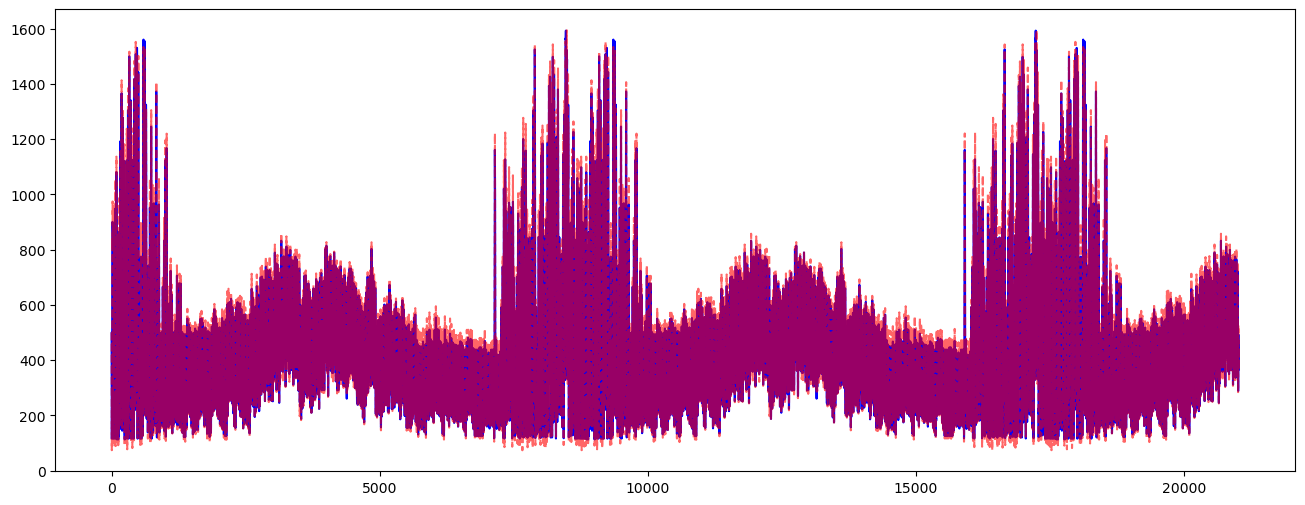

In [21]:
_, ax = plt.subplots(figsize=(16, 6))

ax.plot(y_test_lstm_inv, label="real data", color="blue")
ax.plot(y_pred_lstm, label="predicted data", linestyle="--", color="red",alpha=0.6)

plt.show()


## GRU

In [22]:
# df = pd.read_csv("./data/Load_data_01.csv")
# df


In [23]:
df['Time'] = pd.to_datetime(df['Time'])


In [24]:
df.set_index('Time', inplace=True)


In [25]:
target_variable = "electricity_demand_values"


In [26]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df[[target_variable]])


In [27]:

def create_dataset(data, look_back=1):
    X, Y = [], []
    for i in range(len(data) - look_back - 1):
        a = data[i : (i + look_back), 0]
        X.append(a)
        Y.append(data[i + look_back, 0])
    return np.array(X), np.array(Y)


In [28]:
look_back = 12 
X, y = create_dataset(scaled_data, look_back)


In [29]:

train_size = int(len(X) * 0.67)
test_size = len(X) - train_size
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]


In [30]:

X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))


In [31]:

model = Sequential()
model.add(GRU(50, return_sequences=True, input_shape=(look_back, 1)))
model.add(GRU(50))
model.add(Dense(1))


In [32]:

model.compile(loss="mean_squared_error", optimizer="adam")
model.fit(X_train, y_train, epochs=5, batch_size=64, verbose=2)


Epoch 1/5


2023-12-03 22:32:07.585696: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node Adam/AssignAddVariableOp.


734/734 - 10s - loss: 0.0021 - 10s/epoch - 14ms/step
Epoch 2/5
734/734 - 9s - loss: 8.7059e-04 - 9s/epoch - 12ms/step
Epoch 3/5
734/734 - 9s - loss: 8.2505e-04 - 9s/epoch - 12ms/step
Epoch 4/5
734/734 - 9s - loss: 8.1077e-04 - 9s/epoch - 12ms/step
Epoch 5/5
734/734 - 8s - loss: 7.9634e-04 - 8s/epoch - 11ms/step


In [33]:

train_predict = model.predict(X_train)
test_predict = model.predict(X_test)


723/723 [==============================] - 3s 3ms/step


In [34]:

train_predict = scaler.inverse_transform(train_predict)
y_train = scaler.inverse_transform([y_train])
test_predict = scaler.inverse_transform(test_predict)
y_test = scaler.inverse_transform([y_test])


In [35]:
np.sqrt(mean_squared_error(y_test.T,test_predict)
)


43.62042957318376

In [36]:
r2_score(y_test.T, test_predict)


0.9694200911466286